# U-Net: Convolutional Networks for Biomedical Image Segmentation

## Scope:

This notebook implements U-Net, trains U-Net, evaluate U-Net

So we will go through the follow phases:

|Phase|Objective|
|-|-|
|1|Explore the dataset (transform, augmentation, loader)|
|2|Creating U-Net (write class, explore layers, toy example)|
|3|Training and evaluating (and a lot of experiments)|
|4|Challenge: reduce overfitting for this task|

## Phase 1: Explore the dataset

In [1]:
# We will use the same training dataset U-Net used
# Dataset: from ISBI 2012 (more info at: https://imagej.net/events/isbi-2012-segmentation-challenge)
!wget -q https://downloads.imagej.net/ISBI-2012-challenge.zip -O data-isbi2012.zip
!unzip -q data-isbi2012.zip 2>/dev/null

In [2]:
# extract images from the .tif files
from PIL import Image
import os

def extract_tiff_slices(tif_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    img = Image.open(tif_path)
    num_slices = img.n_frames
    print(tif_path, "has", num_slices, "slices!")

    for i in range(num_slices):
      img.seek(i)
      img.save(os.path.join(output_dir, f"image_{i:02d}.png"))

    print(f"Extracted {i+1} slices to {output_dir}/")

extract_tiff_slices("train-volume.tif", "./data/train/images")
extract_tiff_slices("train-labels.tif", "./data/train/labels")
extract_tiff_slices("test-volume.tif", "./data/test/images")
extract_tiff_slices("test-labels.tif", "./data/test/labels")

train-volume.tif has 30 slices!
Extracted 30 slices to ./data/train/images/
train-labels.tif has 30 slices!
Extracted 30 slices to ./data/train/labels/
test-volume.tif has 30 slices!
Extracted 30 slices to ./data/test/images/
test-labels.tif has 30 slices!
Extracted 30 slices to ./data/test/labels/


In [3]:
# Let's inspect an image and a mask
import numpy as np

img = np.array(Image.open("/kaggle/working/data/train/images/image_00.png"))
mask = np.array(Image.open("/kaggle/working/data/train/labels/image_00.png"))
print(img.shape)
print(mask.shape, np.unique(mask, return_counts=True))
# Image is grayscale, whereas Mask is binary. Both are of shape (512,512).

(512, 512)
(512, 512) (array([  0, 255], dtype=uint8), array([ 57492, 204652]))


In [3]:
# util function for showing images :)
import matplotlib.pyplot as plt
import torch
import numpy as np

def show_img_pair(img1, img2):
  """show img1 and img2 side by side"""
  fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(6,3))
  # case 1: inputs are paths
  if isinstance(img1, str) and isinstance(img1, str):
    img1 = Image.open(img1)
    img2 = Image.open(img2)
    ax1.imshow(img1, cmap='gray')
    ax2.imshow(img2, cmap='gray')

  # case 2: inputs are Tensors
  if isinstance(img1, torch.Tensor) and isinstance(img2, torch.Tensor):
    ax1.imshow(img1.squeeze(0), cmap='gray')
    ax2.imshow(img2.squeeze(0), cmap='gray')

  # case 3: inputs are ndarrays
  if isinstance(img1, np.ndarray) and isinstance(img2, np.ndarray):
    ax1.imshow(img1, cmap='gray')
    ax2.imshow(img2, cmap='gray')

  plt.tight_layout()
  plt.show()

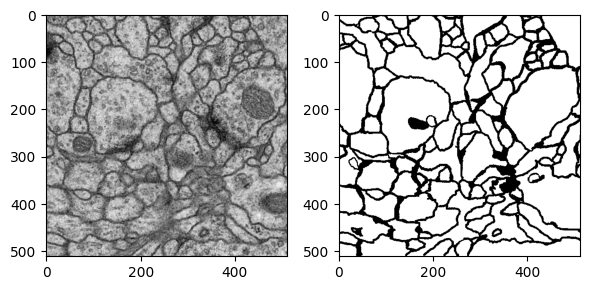

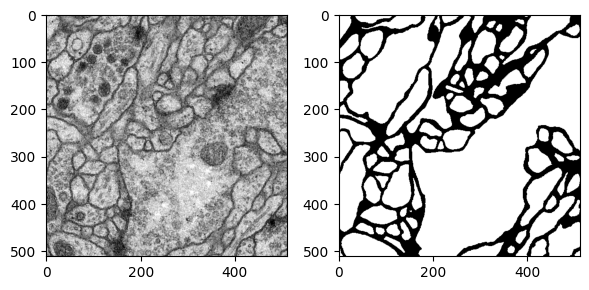

In [5]:
show_img_pair("/kaggle/working/data/train/images/image_00.png", "/kaggle/working/data/train/labels/image_00.png")    # train image-mask
show_img_pair("/kaggle/working/data/test/images/image_00.png", "/kaggle/working/data/test/labels/image_00.png")      # test image-mask

In [4]:
# Now write a Dataset
# Goal: A Dataset instance lets us quickly grab a processed (ie transformed) image-label pair just by indexing
import os
from torch.utils.data import Dataset
from torchvision.io import read_image

class ISBI(Dataset):

  def __init__(self, root, train, transform=None):
    """
    root (str): where to look for your images and labels
    train (bool): True for training set, False for test set
    transform: specify your albumentations transformation
    """
    self.images_dir = os.path.join(root, "train/images/") if train else os.path.join(root, "test/images/")
    self.labels_dir = os.path.join(root, "train/labels/") if train else os.path.join(root, "test/labels/")
    self.images_path = sorted([os.path.join(self.images_dir, i) for i in os.listdir(self.images_dir) if i.endswith(".png")])
    self.labels_path = sorted([os.path.join(self.labels_dir, l) for l in os.listdir(self.labels_dir) if l.endswith(".png")])
    self.transform = transform

  def __len__(self):
    return len(self.images_path)

  def __getitem__(self, index):
    image_path = self.images_path[index]
    image = read_image(image_path)
    label_path = self.labels_path[index]
    label = read_image(label_path)

    if self.transform:
      augmented = self.transform(image=image.squeeze(0).numpy(), mask=label.squeeze(0).numpy())
      image = augmented["image"]
      label = augmented["mask"]

    label = (label / 255).long()  # make labels type torch.int64 with values in {0,1}

    return (image, label)

In [7]:
# Create our Dataset instances
training_data = ISBI(root="/kaggle/working/data", train=True)
test_data = ISBI(root="/kaggle/working//data", train=False)

In [8]:
# Test if indexing works
train_img0, train_label0 = training_data[0]
print(train_img0.shape, train_label0.shape)
test_img0, test_label0 = test_data[0]
print(test_img0.shape, test_label0.shape)

torch.Size([1, 512, 512]) torch.Size([1, 512, 512])
torch.Size([1, 512, 512]) torch.Size([1, 512, 512])


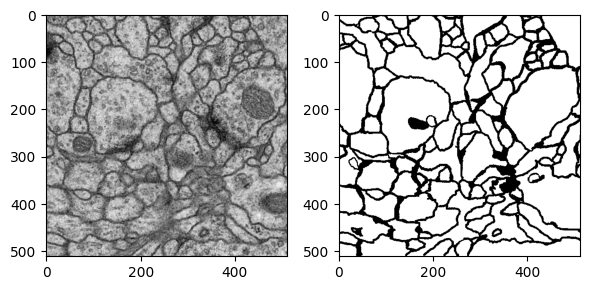

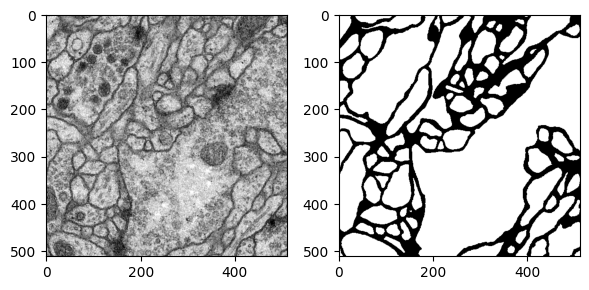

In [9]:
# Test if we actually pull out what we wanted
show_img_pair(train_img0, train_label0)
show_img_pair(test_img0, test_label0)

In [5]:
# However, we want to transform our images and labels
# Currently: images and labels are uint8 values within [0, 255]

import torchvision.transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2

# We want: resize to 572x572 -> augmentation -> normalize (for training) (applied to both images and labels)
train_transform = A.Compose([
    # resize
    A.Resize(height=512, width=512),      # 512 instead of 572 (explanation in phase 2)
    # shift and rotation
    A.Affine(
        translate_percent=[-0.05, 0.05],  # move horizontally or vertically by a factor ~Uniform(-0.05,0.05) that is then used identically for x- and y-axis.
        rotate=[-90, 90],                 # rotate from 90 degrees left to 90 degrees right
        p=0.5                             # 50% probability of this transformation happening
    ),
    # grid elastic deformation
    A.GridElasticDeform(
        num_grid_xy=[3, 3],               # 3x3 grid
        magnitude=10,                     # 10px displacement
        interpolation=1,
        mask_interpolation=0
    ),
    # gray value variation
    A.RandomBrightnessContrast(p=1.0),
    # normalize then convert to tensor
    A.Normalize(mean=0.5, std=0.5),       # uint8 [0,255] -> float[-1.,+1.]
    ToTensorV2()                          # numpy to tensor (albumentations work with arrays internally)
])

# We also want: resize to 572x572 -> normalize (for evaluating)
test_transform = A.Compose([
    # resize
    A.Resize(height=512, width=512),
    # normalize then convert to tensor
    A.Normalize(mean=0.5, std=0.5),       # uint8 [0,255] -> float[-1.,+1.]
    ToTensorV2()                          # numpy to tensor (albumentations work with arrays internally)
])

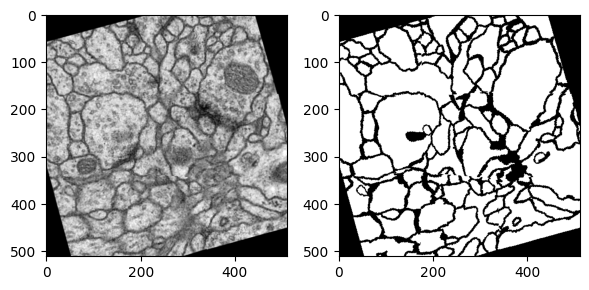

In [11]:
i_train = np.array(Image.open("/kaggle/working/data/train/images/image_00.png"))
l_train = np.array(Image.open("/kaggle/working/data/train/labels/image_00.png"))
augmented = train_transform(image=i_train, mask=l_train)  # A.Compose().__call__(image=, mask=) takes in numpy arrays and returns tensors
show_img_pair(augmented["image"], augmented["mask"])

In [12]:
print(torch.unique(augmented["mask"]))  # still a binary image

tensor([  0, 255], dtype=torch.uint8)


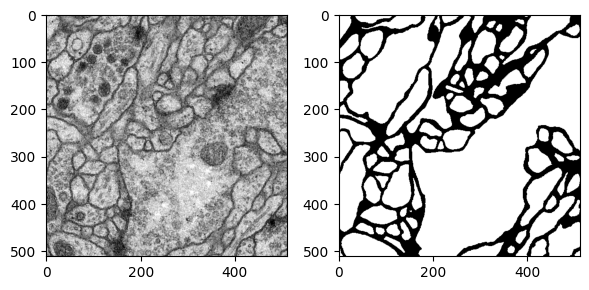

In [13]:
# just resize and normalize, no shift rotate ...
i_test = np.array(Image.open("/kaggle/working/data/test/images/image_00.png"))
l_test = np.array(Image.open("/kaggle/working/data/test/labels/image_00.png"))
augmented_test = test_transform(image=i_test, mask=l_test)
show_img_pair(augmented_test["image"], augmented_test["mask"])

<details>

<summary>🌟 ATTENTION!!</summary>

### ✔️ A quick clarification about `albumentations` and `torchvision.transforms`

Q1. Why we use `albumentations` instead of `torchvision.transforms` for transformation?

A1. `albumentations` can apply simultaneously to both images and labels, whereas `torchvision.transforms` cannot.

Q2. Does `albumentations` know which transformation to apply to the images and the labels?

A2. Yes. `albumentations` categorizes every transform into two types: spatial transformation and pixel-level transformation.

|Type|Example|Applied to|
|-|-|-|
|Spatial transfromation|flip, rotate, shift, deformation, ...|images and labels|
|Pixel-level transformation|brightness, contrast, normalize, ...|images|

</details>

In [14]:
# Now let's write our DataLoader
# Goal: A DataLoader interacts with a Dataset to give us bacthes of data.
# Imagine our Dataset has 10 candies, the DataLoader will shuffle and divide them into 5 batches of 2 candies.

from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)  # Unet uses batch size of 1, resulting in 30 batches of 1 image
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=False)

In [15]:
print("We have", len(train_dataloader), "training batches")

We have 30 training batches


## Phase 2: Creating U-Net

<details>

<summary>🌟 THE BIG PICTURE</summary>

We have already created a Dataset and DataLoaders

We will create a model that inputs a Tensor (1,1,572,572) and outputs (1,2,388,388)

However, the ground truth is (1,1,572,572), so how do we calculate the loss? In other words, how do we deal with dimension mismatch?

The original paper (https://arxiv.org/abs/1505.04597) does this intentionally. That is, they input a big picture and output a smaller picture that is in the middle of the input. Please refer to the paper, its figure 2, and other elaboration.

In this implementation, we will make the input and output dimnesion the same (572,572) for simplicity.

✔️ Nevertheless, we will still implement the original architecture as a reference, while another simplified version is implemented and used for training and inference.

</details>

In [16]:
!pip install -q torchinfo

In [6]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [18]:
# original U-Net
import torch
import torch.nn as nn

class UNet(nn.Module):

  def __init__(self):
    super().__init__()

    self.contracting = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),  # '3'
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),  # '8'
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),  # '13'
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

        nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),  # '18'
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    )

    self.bottleneck = nn.Sequential(
        nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
    )

    self.expansive = nn.Sequential(
        nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1),  # '0'
        nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),

        nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # '5'
        nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),

        nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # '10'
        nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),

        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # '15'
        nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=0),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 2, kernel_size=1, stride=1, padding=0),
    )

  def forward(self, x):
    # contracting path
    crop1, crop2, crop3, crop4 = None, None, None, None
    for name, layer in self.contracting.named_children():
      x = layer(x)
      if name == '3':
        crop1 = self._crop(x, (392,392))
      elif name == '8':
        crop2 = self._crop(x, (200,200))
      elif name == '13':
        crop3 = self._crop(x, (104,104))
      elif name == '18':
        crop4 = self._crop(x, (56,56))

    x = self.bottleneck(x)

    # expansive path
    for name, layer in self.expansive.named_children():
      x = layer(x)
      if name == '0':
        x = torch.cat((crop4,x), dim=1)
      elif name == '5':
        x = torch.cat((crop3,x), dim=1)
      elif name == '10':
        x = torch.cat((crop2,x), dim=1)
      elif name == '15':
        x = torch.cat((crop1,x), dim=1)

    return x

  def _crop(self, x, target):
    """Center-crop x to target (h,w) shape"""
    _, _, h1, w1 = x.shape
    h2, w2 = target
    h_offset = (h1 - h2) // 2
    w_offset = (w1 - w2) // 2
    return x[:,:,h_offset:-h_offset,w_offset:-w_offset]

In [19]:
from torchinfo import summary
summary(UNet().to(device), input_size=(1,1,572,572))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 2, 388, 388]          --
├─Sequential: 1-1                        --                        --
│    └─Conv2d: 2-1                       [1, 64, 570, 570]         640
│    └─ReLU: 2-2                         [1, 64, 570, 570]         --
│    └─Conv2d: 2-3                       [1, 64, 568, 568]         36,928
│    └─ReLU: 2-4                         [1, 64, 568, 568]         --
│    └─MaxPool2d: 2-5                    [1, 64, 284, 284]         --
│    └─Conv2d: 2-6                       [1, 128, 282, 282]        73,856
│    └─ReLU: 2-7                         [1, 128, 282, 282]        --
│    └─Conv2d: 2-8                       [1, 128, 280, 280]        147,584
│    └─ReLU: 2-9                         [1, 128, 280, 280]        --
│    └─MaxPool2d: 2-10                   [1, 128, 140, 140]        --
│    └─Conv2d: 2-11                      [1, 256, 138, 138]        295,

In [7]:
# our simplified UNet
import torch
import torch.nn as nn

class SimpleUNet(nn.Module):

  def __init__(self):
    """
    Modification: The bottleneck dimension should be 32.
    We work our way up the contracting path: 32 -> 64 -> 128 -> 256 -> 512 (new input dim).
    Apply this to the expansive path also.
    Still 4 skip connections but no more center crops. Now we concat the whole map.
    Use padded convolution to keep the dimension instead of unpadded ones.
    I also add BatchNorm2D
    """
    super().__init__()

    self.contracting = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),  # '5' (BN)
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),  # '12' (BN)
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),  # '19' (BN)
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

        nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),  # '26' (BN)
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    )

    self.bottleneck = nn.Sequential(
        nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(1024),
        nn.ReLU(inplace=True),
        nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(1024),
        nn.ReLU(inplace=True),
    )

    self.expansive = nn.Sequential(
        nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1),  # '0'
        nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),

        nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # '7' (BN)
        nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),

        nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # '14' (BN)
        nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),

        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # '21' (BN)
        nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 2, kernel_size=1, stride=1, padding=0),
    )

  def forward(self, x):
    # contracting path
    crop1, crop2, crop3, crop4 = None, None, None, None
    for name, layer in self.contracting.named_children():
      x = layer(x)
      if name == '5':
        crop1 = x
      elif name == '12':
        crop2 = x
      elif name == '19':
        crop3 = x
      elif name == '26':
        crop4 = x

    x = self.bottleneck(x)

    # expansive path
    for name, layer in self.expansive.named_children():
      x = layer(x)
      if name == '0':
        x = torch.cat((crop4,x), dim=1)
      elif name == '7':
        x = torch.cat((crop3,x), dim=1)
      elif name == '14':
        x = torch.cat((crop2,x), dim=1)
      elif name == '21':
        x = torch.cat((crop1,x), dim=1)

    return x

In [21]:
from torchinfo import summary
m = SimpleUNet().to(device)
summary(m, input_size=(1,1,512,512))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleUNet                               [1, 2, 512, 512]          --
├─Sequential: 1-1                        --                        --
│    └─Conv2d: 2-1                       [1, 64, 512, 512]         640
│    └─BatchNorm2d: 2-2                  [1, 64, 512, 512]         128
│    └─ReLU: 2-3                         [1, 64, 512, 512]         --
│    └─Conv2d: 2-4                       [1, 64, 512, 512]         36,928
│    └─BatchNorm2d: 2-5                  [1, 64, 512, 512]         128
│    └─ReLU: 2-6                         [1, 64, 512, 512]         --
│    └─MaxPool2d: 2-7                    [1, 64, 256, 256]         --
│    └─Conv2d: 2-8                       [1, 128, 256, 256]        73,856
│    └─BatchNorm2d: 2-9                  [1, 128, 256, 256]        256
│    └─ReLU: 2-10                        [1, 128, 256, 256]        --
│    └─Conv2d: 2-11                      [1, 128, 256, 256]        147,58

In [22]:
# Now let's try calculate a loss
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [23]:
# recreating a training set with transformed data
training_data = ISBI(root="/kaggle/working/data", train=True, transform=train_transform)

# two methods of getting (img, label)
# method 1 (used in training)
train_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)
for img, label in train_dataloader:
  print(img.shape, img.dtype)
  print(label.shape, label.dtype, torch.unique(label))
  break

# method 2 (used now for simplicity)
img, label = training_data[1]
img = img.unsqueeze(0).to(device)
label = label.unsqueeze(0).to(device)
print(img.shape, img.dtype)
print(label.shape, label.dtype, torch.unique(label))

torch.Size([1, 1, 512, 512]) torch.float32
torch.Size([1, 512, 512]) torch.int64 tensor([0, 1])
torch.Size([1, 1, 512, 512]) torch.float32
torch.Size([1, 512, 512]) torch.int64 tensor([0, 1], device='cuda:0')


In [24]:
pred = m(img)
print(pred.shape, pred.dtype)

torch.Size([1, 2, 512, 512]) torch.float32


In [25]:
loss = criterion(pred, label).item()
print(loss)

0.6850859522819519


In [8]:
# in case we want to visualize our pred (1,2,512,512)
def pred_to_mask(pred):
  """turn pred tensor(1,2,512,512) to mask ndarray(512,512)"""
  pred = pred.cpu()
  return torch.argmax(pred.squeeze(0), dim=0).numpy()

In [27]:
mask = pred_to_mask(pred)
print(mask.shape, np.unique(mask))

(512, 512) [0 1]


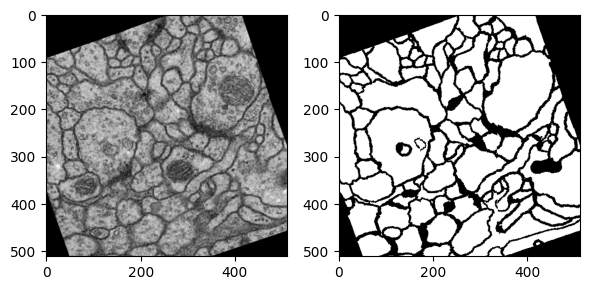

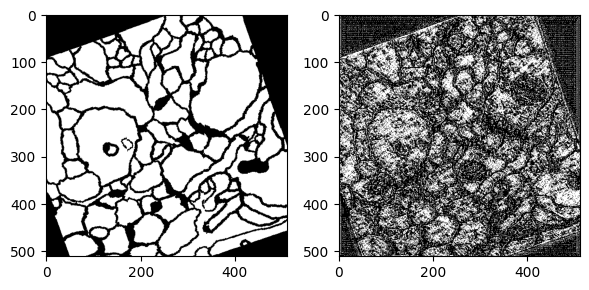

In [29]:
# visualize pred
show_img_pair(img.cpu().squeeze().numpy(), label.cpu().squeeze(0).numpy())  # img vs gt
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

## Phase 3: Training and evaluating

In [30]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using", device)

Using cuda


In [42]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):

  model.train()
  total_loss = 0.

  for img, label in dataloader:
    img = img.to(device)
    label = label.to(device)
    pred = model(img)
    loss = loss_fn(pred,label)
    total_loss += loss.item()

    # L1 regularization
    l1_lambda = 1e-5
    l1_reg = sum(p.abs().sum() for p in model.parameters())
    l1_loss = l1_lambda * l1_reg

    # L2 regularization
    l2_lambda = 1e-4
    l2_reg = sum(p.pow(2).sum() for p in model.parameters())
    l2_loss = l2_lambda * l2_reg

    # Combined loss
    loss = loss + l1_loss + l2_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  num_batch = len(dataloader)

  return total_loss / num_batch

In [10]:
def dice_score(logits, target, smooth=1e-6):
    """logits (1,2,512,512) target(1,1,512,512)"""
    probs = logits.softmax(dim=1)[:, 1]  # (1,512,512)
    pred = (probs > 0.5).float()
    target = target.squeeze(1).float()   # (1,512,512)
    
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

In [11]:
def evaluate(dataloader, model, loss_fn):

  model.eval()
  total_loss = 0.
  total_dice = 0.

  with torch.no_grad():
    for img, label in dataloader:
      img = img.to(device)
      label = label.to(device)
      pred = model(img)
      loss = loss_fn(pred,label)
      total_loss += loss.item()
      dice = dice_score(pred, label)
      total_dice += dice.item()

  num_batch = len(dataloader)

  return total_loss / num_batch, total_dice / num_batch

In [14]:
def train(train_dataloader, test_dataloader, model, loss_fn, optimizer, epochs):

  history_train = []
  history_test = []
  history_dice = []
  for i in range(epochs):
    total_loss_train = train_one_epoch(train_dataloader, model, loss_fn, optimizer)
    total_loss_test, total_dice = evaluate(test_dataloader, model, loss_fn)
    history_train.append(total_loss_train)
    history_test.append(total_loss_test)
    history_dice.append(total_dice)
    if i % 5 == 0:
      print(f"Epoch {i}: Train loss {total_loss_train:.4f}\tTest loss: {total_loss_test:.4f}\tDice score: {total_dice:.4f}")

  return history_train, history_test, history_dice

In [15]:
import matplotlib.pyplot as plt

def show_loss(history_train, history_test, history_dice):
  plt.figure(figsize=(4,4))
  plt.plot(history_train, label="train loss")
  plt.plot(history_test, label="test loss")
  plt.plot(history_dice, label="Dice score")
  plt.legend()
  plt.tight_layout()
  plt.xlabel("epoch")
  plt.ylabel("loss")
  plt.show()

### 🗜️ Experiment 1: No regularization

In [58]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

model = SimpleUNet().to(device)
training_data = ISBI(root="/kaggle/working/data", train=True, transform=train_transform)
test_data = ISBI(root="/kaggle/working/data", train=False, transform=test_transform)
train_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [59]:
history_train, history_test = train(train_dataloader, test_dataloader, model, criterion, optimizer, 50)

Epoch 0: Train loss 0.4543	Test loss: 0.4890	Dice score: 0.8513
Epoch 1: Train loss 0.3529	Test loss: 0.4315	Dice score: 0.8566
Epoch 2: Train loss 0.3312	Test loss: 0.4409	Dice score: 0.8588
Epoch 3: Train loss 0.3239	Test loss: 0.4395	Dice score: 0.8599
Epoch 4: Train loss 0.3143	Test loss: 0.4284	Dice score: 0.8653
Epoch 5: Train loss 0.2989	Test loss: 0.4579	Dice score: 0.8662
Epoch 6: Train loss 0.2890	Test loss: 0.5047	Dice score: 0.8586
Epoch 7: Train loss 0.2883	Test loss: 0.4257	Dice score: 0.8731
Epoch 8: Train loss 0.2717	Test loss: 0.5945	Dice score: 0.8554
Epoch 9: Train loss 0.2676	Test loss: 0.5765	Dice score: 0.8577
Epoch 10: Train loss 0.2622	Test loss: 0.7137	Dice score: 0.8516
Epoch 11: Train loss 0.2610	Test loss: 0.5590	Dice score: 0.8629
Epoch 12: Train loss 0.2536	Test loss: 0.7042	Dice score: 0.8528
Epoch 13: Train loss 0.2456	Test loss: 0.6782	Dice score: 0.8575
Epoch 14: Train loss 0.2421	Test loss: 0.6881	Dice score: 0.8617
Epoch 15: Train loss 0.2432	Test lo

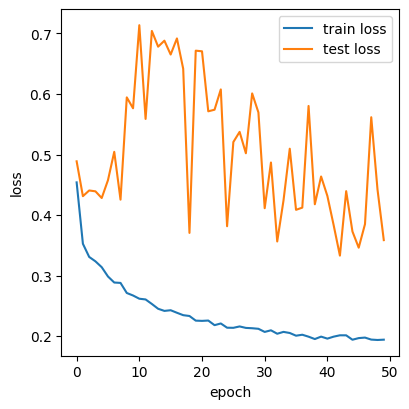

In [61]:
show_loss(history_train, history_test)

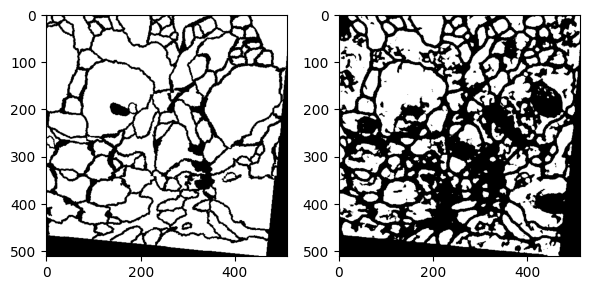

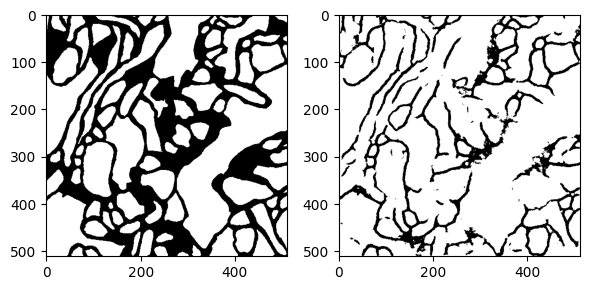

In [68]:
img, label = training_data[0]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

img, label = test_data[10]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

Looks like overfitting :)

### 🗜️ Experiment 2: L1 regularization

In [33]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

model = SimpleUNet().to(device)
training_data = ISBI(root="/kaggle/working/data", train=True, transform=train_transform)
test_data = ISBI(root="/kaggle/working/data", train=False, transform=test_transform)
train_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [34]:
history_train, history_test, history_dice = train(train_dataloader, test_dataloader, model, criterion, optimizer, 50)

Epoch 0: Train loss 0.4495	Test loss: 0.4963	Dice score: 0.8512
Epoch 5: Train loss 0.3077	Test loss: 0.5045	Dice score: 0.8578
Epoch 10: Train loss 0.2667	Test loss: 0.5758	Dice score: 0.8603
Epoch 15: Train loss 0.2473	Test loss: 0.3839	Dice score: 0.8917
Epoch 20: Train loss 0.2262	Test loss: 0.5255	Dice score: 0.8761
Epoch 25: Train loss 0.2170	Test loss: 0.4707	Dice score: 0.8868
Epoch 30: Train loss 0.2075	Test loss: 0.5271	Dice score: 0.8848
Epoch 35: Train loss 0.2040	Test loss: 0.4300	Dice score: 0.8924
Epoch 40: Train loss 0.1979	Test loss: 0.4446	Dice score: 0.8893
Epoch 45: Train loss 0.1918	Test loss: 0.5865	Dice score: 0.8760


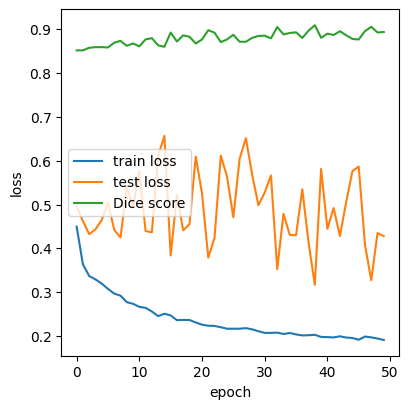

In [35]:
show_loss(history_train, history_test, history_dice)

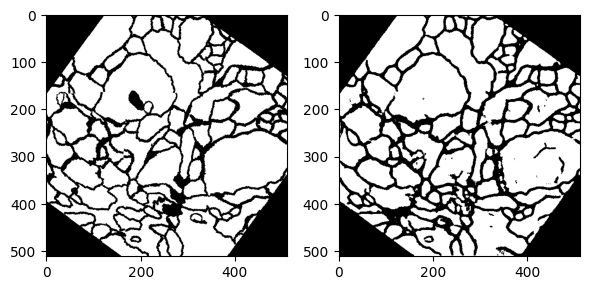

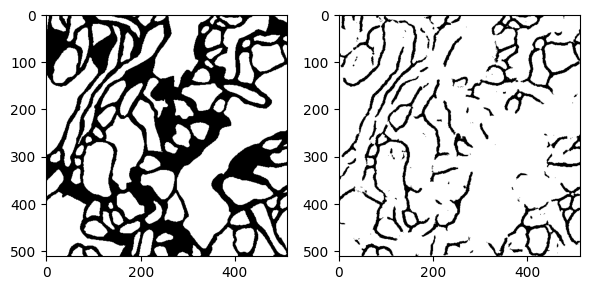

In [27]:
img, label = training_data[0]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

img, label = test_data[10]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

### 🗜️ Experiment 3: L2 regularization

In [37]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

model = SimpleUNet().to(device)
training_data = ISBI(root="/kaggle/working/data", train=True, transform=train_transform)
test_data = ISBI(root="/kaggle/working/data", train=False, transform=test_transform)
train_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [38]:
history_train, history_test, history_dice = train(train_dataloader, test_dataloader, model, criterion, optimizer, 50)

Epoch 0: Train loss 0.4427	Test loss: 0.4903	Dice score: 0.8500
Epoch 5: Train loss 0.3086	Test loss: 0.5523	Dice score: 0.8526
Epoch 10: Train loss 0.2667	Test loss: 0.5744	Dice score: 0.8565
Epoch 15: Train loss 0.2413	Test loss: 0.6307	Dice score: 0.8624
Epoch 20: Train loss 0.2276	Test loss: 0.6015	Dice score: 0.8701
Epoch 25: Train loss 0.2159	Test loss: 0.5145	Dice score: 0.8841
Epoch 30: Train loss 0.2060	Test loss: 0.5099	Dice score: 0.8828
Epoch 35: Train loss 0.2048	Test loss: 0.4088	Dice score: 0.8953
Epoch 40: Train loss 0.1975	Test loss: 0.3806	Dice score: 0.8968
Epoch 45: Train loss 0.1969	Test loss: 0.4613	Dice score: 0.8907


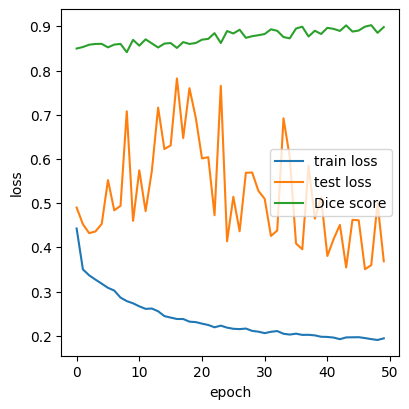

In [39]:
show_loss(history_train, history_test, history_dice)

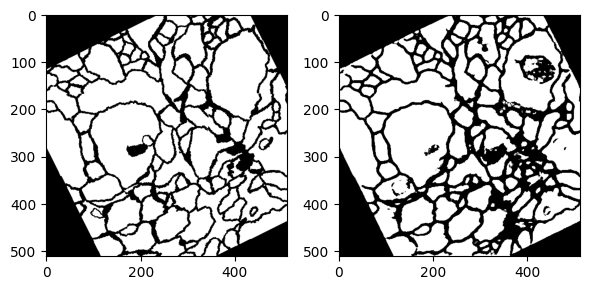

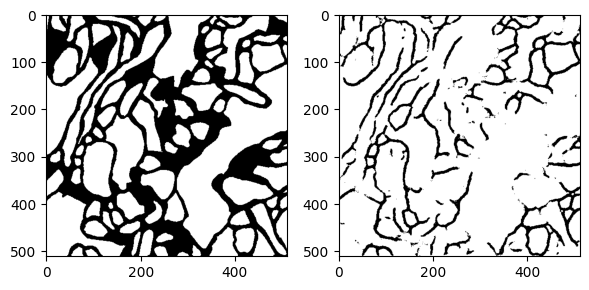

In [41]:
img, label = training_data[0]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

img, label = test_data[10]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

### 🗜️ Experiment 4: L1 + L2 regularization

In [43]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

model = SimpleUNet().to(device)
training_data = ISBI(root="/kaggle/working/data", train=True, transform=train_transform)
test_data = ISBI(root="/kaggle/working/data", train=False, transform=test_transform)
train_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [44]:
history_train, history_test, history_dice = train(train_dataloader, test_dataloader, model, criterion, optimizer, 50)

Epoch 0: Train loss 0.4330	Test loss: 0.5011	Dice score: 0.8407
Epoch 5: Train loss 0.3039	Test loss: 0.5058	Dice score: 0.8578
Epoch 10: Train loss 0.2626	Test loss: 0.4803	Dice score: 0.8702
Epoch 15: Train loss 0.2358	Test loss: 0.5702	Dice score: 0.8628
Epoch 20: Train loss 0.2227	Test loss: 0.6133	Dice score: 0.8700
Epoch 25: Train loss 0.2175	Test loss: 0.5161	Dice score: 0.8797
Epoch 30: Train loss 0.2076	Test loss: 0.5911	Dice score: 0.8753
Epoch 35: Train loss 0.2028	Test loss: 0.4992	Dice score: 0.8875
Epoch 40: Train loss 0.1986	Test loss: 0.4862	Dice score: 0.8866
Epoch 45: Train loss 0.1925	Test loss: 0.3618	Dice score: 0.9026


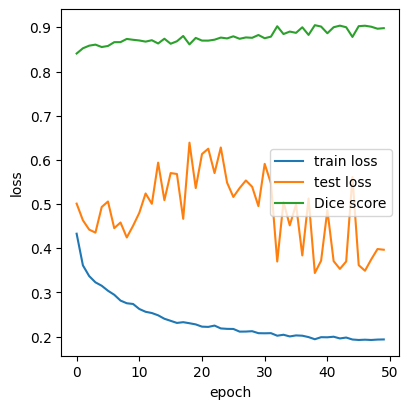

In [45]:
show_loss(history_train, history_test, history_dice)

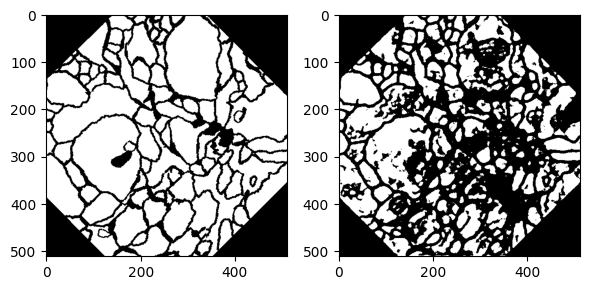

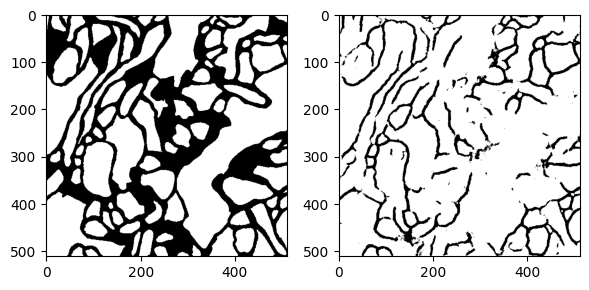

In [51]:
img, label = training_data[0]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

img, label = test_data[10]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

## Phase 4: Challenge: Reduce overfitting

### 🗜️ Experiment 1: Reduce model complexity

In [52]:
# our simplified UNet
import torch
import torch.nn as nn

class EvenSimplerUNet(nn.Module):

  def __init__(self):
    """
    Modification: The bottleneck dimension should be 64 (double the SimpleUnet).
    3 skip connections (instead of 4)
    """
    super().__init__()

    self.contracting = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),  # '5' (BN)
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),  # '12' (BN)
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),  # '19' (BN)
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

        # nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
        # nn.BatchNorm2d(512),
        # nn.ReLU(inplace=True),
        # nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
        # nn.BatchNorm2d(512),
        # nn.ReLU(inplace=True),  # '26' (BN)
        # nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    )

    self.bottleneck = nn.Sequential(
        nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
    )

    self.expansive = nn.Sequential(
        # nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1),  # '0'
        # nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
        # nn.BatchNorm2d(512),
        # nn.ReLU(inplace=True),
        # nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
        # nn.BatchNorm2d(512),
        # nn.ReLU(inplace=True),

        nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # '7' (BN)
        nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),

        nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # '14' (BN)
        nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),

        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # '21' (BN)
        nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 2, kernel_size=1, stride=1, padding=0),
    )

  def forward(self, x):
    # contracting path
    crop1, crop2, crop3, crop4 = None, None, None, None
    for name, layer in self.contracting.named_children():
      x = layer(x)
      if name == '5':
        crop1 = x
      elif name == '12':
        crop2 = x
      elif name == '19':
        crop3 = x
      # elif name == '26':
        # crop4 = x

    x = self.bottleneck(x)

    # expansive path
    for name, layer in self.expansive.named_children():
      x = layer(x)
      # if name == '0':
        # x = torch.cat((crop4,x), dim=1)
      if name == '0':
        x = torch.cat((crop3,x), dim=1)
      elif name == '7':
        x = torch.cat((crop2,x), dim=1)
      elif name == '14':
        x = torch.cat((crop1,x), dim=1)

    return x

In [81]:
from torchinfo import summary
summary(EvenSimplerUNet().to(device), input_size=(1,1,512,512))

Layer (type:depth-idx)                   Output Shape              Param #
EvenSimplerUNet                          [1, 2, 512, 512]          --
├─Sequential: 1-1                        --                        --
│    └─Conv2d: 2-1                       [1, 64, 512, 512]         640
│    └─BatchNorm2d: 2-2                  [1, 64, 512, 512]         128
│    └─ReLU: 2-3                         [1, 64, 512, 512]         --
│    └─Conv2d: 2-4                       [1, 64, 512, 512]         36,928
│    └─BatchNorm2d: 2-5                  [1, 64, 512, 512]         128
│    └─ReLU: 2-6                         [1, 64, 512, 512]         --
│    └─MaxPool2d: 2-7                    [1, 64, 256, 256]         --
│    └─Conv2d: 2-8                       [1, 128, 256, 256]        73,856
│    └─BatchNorm2d: 2-9                  [1, 128, 256, 256]        256
│    └─ReLU: 2-10                        [1, 128, 256, 256]        --
│    └─Conv2d: 2-11                      [1, 128, 256, 256]        147,58

In [53]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

model = EvenSimplerUNet().to(device)
training_data = ISBI(root="/kaggle/working/data", train=True, transform=train_transform)
test_data = ISBI(root="/kaggle/working/data", train=False, transform=test_transform)
train_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [54]:
history_train, history_test, history_dice = train(train_dataloader, test_dataloader, model, criterion, optimizer, 50)

Epoch 0: Train loss 0.4211	Test loss: 0.4677	Dice score: 0.8563
Epoch 5: Train loss 0.2981	Test loss: 0.5470	Dice score: 0.8513
Epoch 10: Train loss 0.2605	Test loss: 0.5200	Dice score: 0.8646
Epoch 15: Train loss 0.2388	Test loss: 0.5902	Dice score: 0.8696
Epoch 20: Train loss 0.2271	Test loss: 0.5520	Dice score: 0.8762
Epoch 25: Train loss 0.2143	Test loss: 0.5799	Dice score: 0.8735
Epoch 30: Train loss 0.2074	Test loss: 0.6645	Dice score: 0.8742
Epoch 35: Train loss 0.2039	Test loss: 0.4062	Dice score: 0.8969
Epoch 40: Train loss 0.1995	Test loss: 0.3344	Dice score: 0.9046
Epoch 45: Train loss 0.1923	Test loss: 0.5907	Dice score: 0.8803


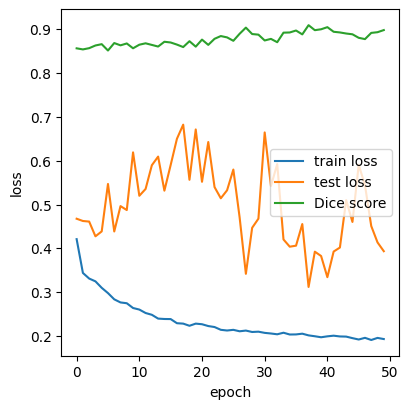

In [55]:
show_loss(history_train, history_test, history_dice)

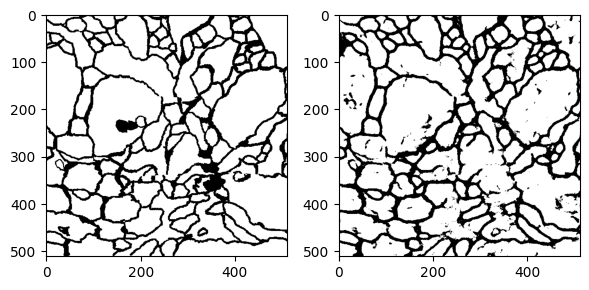

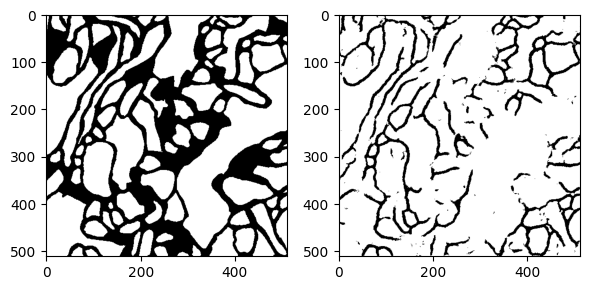

In [65]:
img, label = training_data[0]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

img, label = test_data[10]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

still overfitting :)

### 🗜️ Experiment 2: Try stronger augmentation

In [66]:
import torchvision.transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform_stronger = A.Compose([
    A.Resize(height=512, width=512),

    # --- Spatial transforms (more aggressive) ---
    A.Affine(
        translate_percent=[-0.1, 0.1],   # doubled translation range
        rotate=[-180, 180],              # full rotation range
        shear=[-15, 15],                 # added shear
        scale=[0.8, 1.2],               # added zoom in/out
        p=0.7                            # higher probability
    ),

    # Flip augmentations (free augmentation, very effective)
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    # Stronger elastic deformation
    A.GridElasticDeform(
        num_grid_xy=[4, 4],             # finer grid
        magnitude=20,                   # doubled magnitude
        interpolation=1,
        mask_interpolation=0,
        p=0.7
    ),

    # --- Intensity/color transforms (more variety) ---
    A.RandomBrightnessContrast(
        brightness_limit=0.3,           # explicit stronger limits
        contrast_limit=0.3,
        p=1.0
    ),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),      # simulate focus variation
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),   # simulate sensor noise
    A.RandomGamma(gamma_limit=(70, 130), p=0.3),   # gamma variation

    # --- Occlusion robustness ---
    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(20, 60),
        hole_width_range=(20, 60),
        fill=0,
        p=0.3
    ),

    # --- Normalize then convert to tensor ---
    A.Normalize(mean=0.5, std=0.5),
    ToTensorV2()
])

In [67]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

model = EvenSimplerUNet().to(device)
training_data = ISBI(root="/kaggle/working/data", train=True, transform=train_transform_stronger)
test_data = ISBI(root="/kaggle/working/data", train=False, transform=test_transform)
train_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [68]:
history_train, history_test, history_dice = train(train_dataloader, test_dataloader, model, criterion, optimizer, 50)

Epoch 0: Train loss 0.4375	Test loss: 0.4939	Dice score: 0.8528
Epoch 5: Train loss 0.3167	Test loss: 0.4834	Dice score: 0.8563
Epoch 10: Train loss 0.3063	Test loss: 0.4551	Dice score: 0.8685
Epoch 15: Train loss 0.2668	Test loss: 0.4450	Dice score: 0.8757
Epoch 20: Train loss 0.2527	Test loss: 0.4600	Dice score: 0.8795
Epoch 25: Train loss 0.2421	Test loss: 0.4327	Dice score: 0.8850
Epoch 30: Train loss 0.2404	Test loss: 0.6617	Dice score: 0.8627
Epoch 35: Train loss 0.2263	Test loss: 0.4479	Dice score: 0.8855
Epoch 40: Train loss 0.2244	Test loss: 0.5364	Dice score: 0.8786
Epoch 45: Train loss 0.2135	Test loss: 0.4428	Dice score: 0.8888


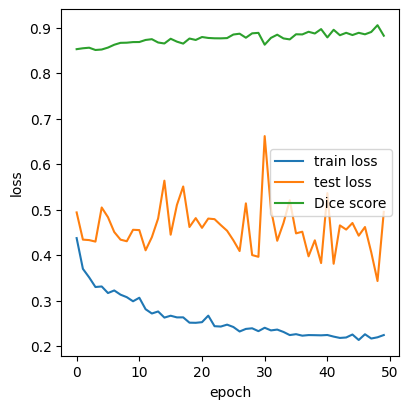

In [69]:
show_loss(history_train, history_test, history_dice)

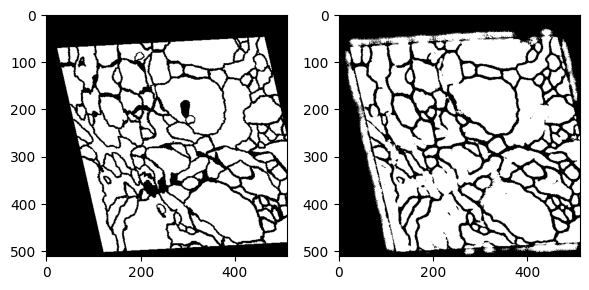

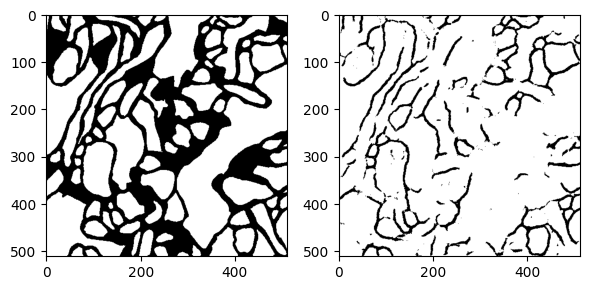

In [72]:
img, label = training_data[0]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

img, label = test_data[10]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

still not successful yet. data augmentation may help reduce overfitting in real world scenarios, but perhaps to make the model perform well on this test set, we might not need any augmentation at all.

### 🗜️ Experiment 3: No augmentation

In [73]:
import torchvision.transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform_weak = A.Compose([
    A.Resize(height=512, width=512),
    A.Normalize(mean=0.5, std=0.5),
    ToTensorV2()
])

In [74]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

model = EvenSimplerUNet().to(device)
training_data = ISBI(root="/kaggle/working/data", train=True, transform=train_transform_weak)
test_data = ISBI(root="/kaggle/working/data", train=False, transform=test_transform)
train_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [75]:
history_train, history_test, history_dice = train(train_dataloader, test_dataloader, model, criterion, optimizer, 50)

Epoch 0: Train loss 0.4634	Test loss: 0.4882	Dice score: 0.8518
Epoch 5: Train loss 0.2970	Test loss: 0.4368	Dice score: 0.8687
Epoch 10: Train loss 0.2577	Test loss: 0.4377	Dice score: 0.8798
Epoch 15: Train loss 0.2327	Test loss: 0.3971	Dice score: 0.8922
Epoch 20: Train loss 0.2128	Test loss: 0.3837	Dice score: 0.8954
Epoch 25: Train loss 0.2016	Test loss: 0.4266	Dice score: 0.8895
Epoch 30: Train loss 0.1921	Test loss: 0.3423	Dice score: 0.9091
Epoch 35: Train loss 0.1801	Test loss: 0.3444	Dice score: 0.9062
Epoch 40: Train loss 0.1708	Test loss: 0.3728	Dice score: 0.9052
Epoch 45: Train loss 0.1578	Test loss: 0.4438	Dice score: 0.8971


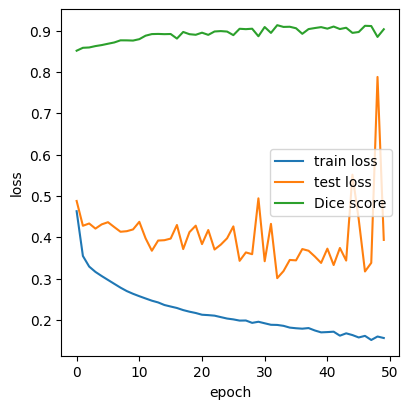

In [76]:
show_loss(history_train, history_test, history_dice)

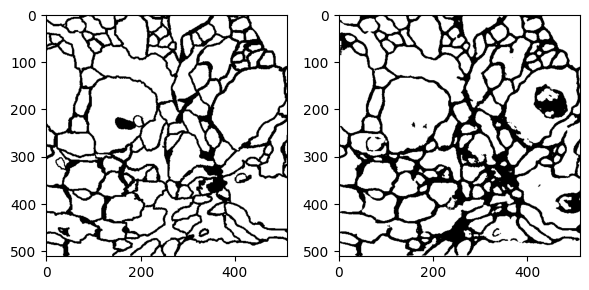

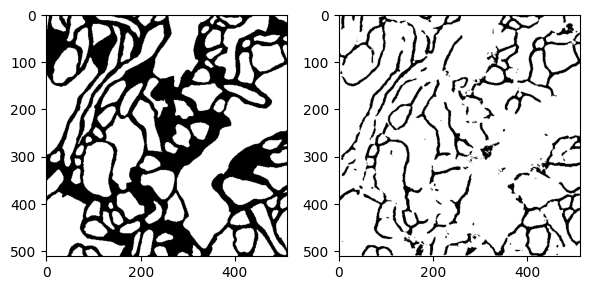

In [78]:
img, label = training_data[0]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

img, label = test_data[10]
img = img.to(device).unsqueeze(0)
label = label.to(device)
pred = model(img)
mask = pred_to_mask(pred)
show_img_pair(label.cpu().squeeze(0).numpy(), mask)  # gt vs pred

Not there yet :) but better than previous runs. Nevertheless, this result doesn't accurately represent how good the model might be in reality (this is cheating xD). The training set is also very small to draw meaningful conclusion.